# House Price Prediction - ML Pipeline
## София Кан | 11.06.2026

## 1. Постановка задачи

В данном проекте используется Ames Housing Dataset — датасет с информацией о жилых домах в городе Эймс, штат Айова. Он содержит различные характеристики недвижимости: площадь дома и участка, количество комнат, качество материалов, год постройки, состояние здания и так далее.

Целевая переменная - **SalePrice** - цена продажи дома. Необходимо построить модель, которая сможет по данным ей признакам предсказать стоимость определенного дома. 


Тип задачи: Регрессия

Метрики успеха:
- **MAE** - средняя абсолютная ошибка.
- **RMSE** - корень среднеквадратичной ошибки. 
- **R2** - доля общей вариации, объясненная моделью. 


## 2. Загрузка данных и первичный осмотр

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import matplotlib.ticker as ticker

In [54]:
%reload_ext autoreload
%autoreload 2

import shutil
import os

cache_path = "/home/sonya/dev/oshka/internship-week-1/week-2/__pycache__"

if os.path.exists(cache_path):
    shutil.rmtree(cache_path)

print("cache removed")

cache removed


In [55]:
from project_eda import * 
from project_modeling import *
from project_preprocessing import *

In [56]:
housing_df = pd.read_csv('./datasets/AmesHousing.csv', index_col='Order')

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None) # иначе все не показывает

housing_df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [57]:
housing_df.describe()

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,2929.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2928.000000,2928.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2771.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,49.722431,559.262547,1051.614544,1159.557679,335.455973,4.676792,1499.690444,0.431352,0.061134,1.566553,0.379522,2.854266,1.044369,6.443003,0.599317,1978.132443,1.766815,472.819734,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,169.168476,439.494153,440.615067,391.890885,428.395715,46.310510,505.508887,0.524820,0.245254,0.552941,0.502629,0.827731,0.214076,1.572964,0.647921,25.528411,0.760566,215.046549,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,219.000000,793.000000,876.250000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,466.000000,990.000000,1084.000000,0.000000,0.000000,1442.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,0.000000,802.000000,1302.000000,1384.000000,703.750000,0.000000,1742.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [58]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2930 entries, 1 to 2930
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   object 
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   object 
 6   Alley            198 non-null    object 
 7   Lot Shape        2930 non-null   object 
 8   Land Contour     2930 non-null   object 
 9   Utilities        2930 non-null   object 
 10  Lot Config       2930 non-null   object 
 11  Land Slope       2930 non-null   object 
 12  Neighborhood     2930 non-null   object 
 13  Condition 1      2930 non-null   object 
 14  Condition 2      2930 non-null   object 
 15  Bldg Type        2930 non-null   object 
 16  House Style      2930 non-null   object 
 17  Overall Qual     29

In [59]:
housing_df.dtypes.value_counts()

object     43
int64      27
float64    11
Name: count, dtype: int64

In [60]:
object_cols = housing_df.select_dtypes(include=['object']).columns.tolist()
num_cols = housing_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

housing_df[object_cols].nunique().sort_values(ascending=False)

Neighborhood      28
Exterior 2nd      17
Exterior 1st      16
Sale Type         10
Condition 1        9
House Style        8
Functional         8
Roof Matl          8
Condition 2        8
MS Zoning          7
Roof Style         6
BsmtFin Type 1     6
Sale Condition     6
Heating            6
Foundation         6
Garage Type        6
BsmtFin Type 2     6
Lot Config         5
Kitchen Qual       5
Misc Feature       5
Garage Cond        5
Garage Qual        5
Exter Cond         5
Fireplace Qu       5
Bsmt Cond          5
Bldg Type          5
Bsmt Qual          5
Heating QC         5
Electrical         5
Bsmt Exposure      4
Exter Qual         4
Land Contour       4
Lot Shape          4
Mas Vnr Type       4
Pool QC            4
Fence              4
Garage Finish      3
Land Slope         3
Utilities          3
Paved Drive        3
Alley              2
Street             2
Central Air        2
dtype: int64

## 3. EDA

Эта секция содержит данные пункты:
* Распределение целевой переменной

* Распределения признаков

* Визуализации отношений между признаками и целевой переменной

* Визаулизации отношений между признаками

* Корреляционная матрица

* Проверка мультиколлинеарности

* Анализ выбросов и общего качества данных

* Анализ пропущенных значений 


Такое большое количество подсекций объясняется большим количеством признаков в датасете и сложностью его структуры. 

In [61]:
sns.set_style("darkgrid")

### Распределение целевой переменной

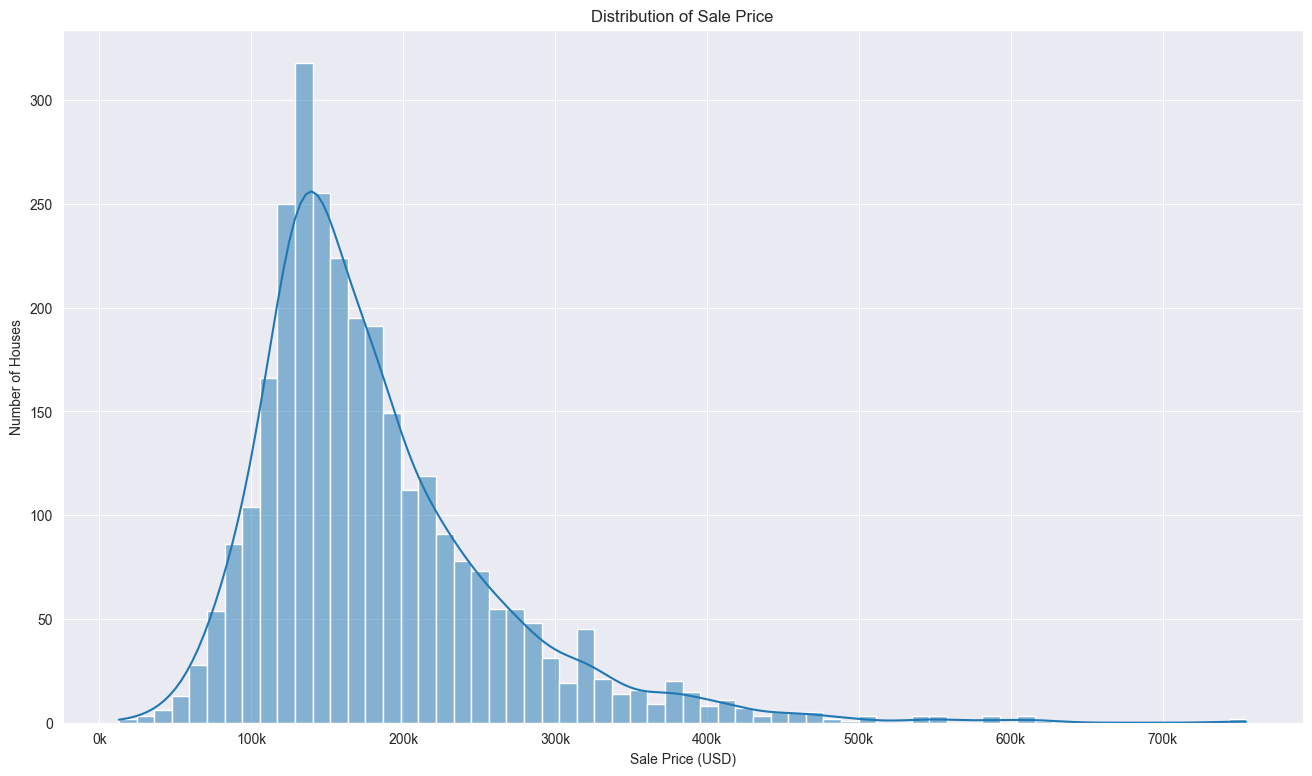

In [62]:
plot_target_distribution(housing_df) 

In [63]:
print(housing_df['SalePrice'].skew())
print(housing_df['SalePrice'].median())

1.7435000757376466
160000.0


Вывод: Распределение сильно ассиметрично, скошено в право. Большинство значений находятся в ценовом диапазоне от 120 до 200 тысяч долларов, но есть небольшое количество высоких выбросов с стоимостью до 700 тыс. долларов.Медианное значение стоимости составляет 160 тысяч долларов, коэффициент асимметрии - 1.74.

### Числовые признаки с средней и высокой корреляцией с целевой переменной:

Чтобы не делать отдельные графики распределения для всех 38 численных признаков в датасете, было решено найти те, которые имеют наибольший коэффициент корреляции с целевой переменной и сделать распределения для них.  

Ниже приведена визуализация, отображающая 14 таковых признаков с их соответствующим коэффициентом корреляции. 

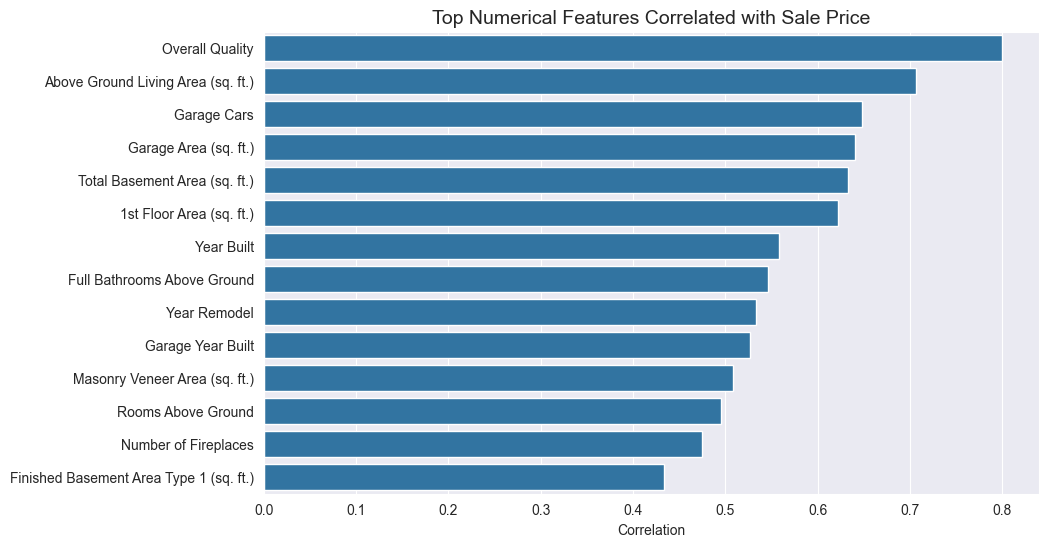

In [64]:
top_corr = plot_top_correlations(
    housing_df,
    threshold=0.4 
)

### Распределения 10 числовых признаков с самой высокой корреляцией с целевой переменной:

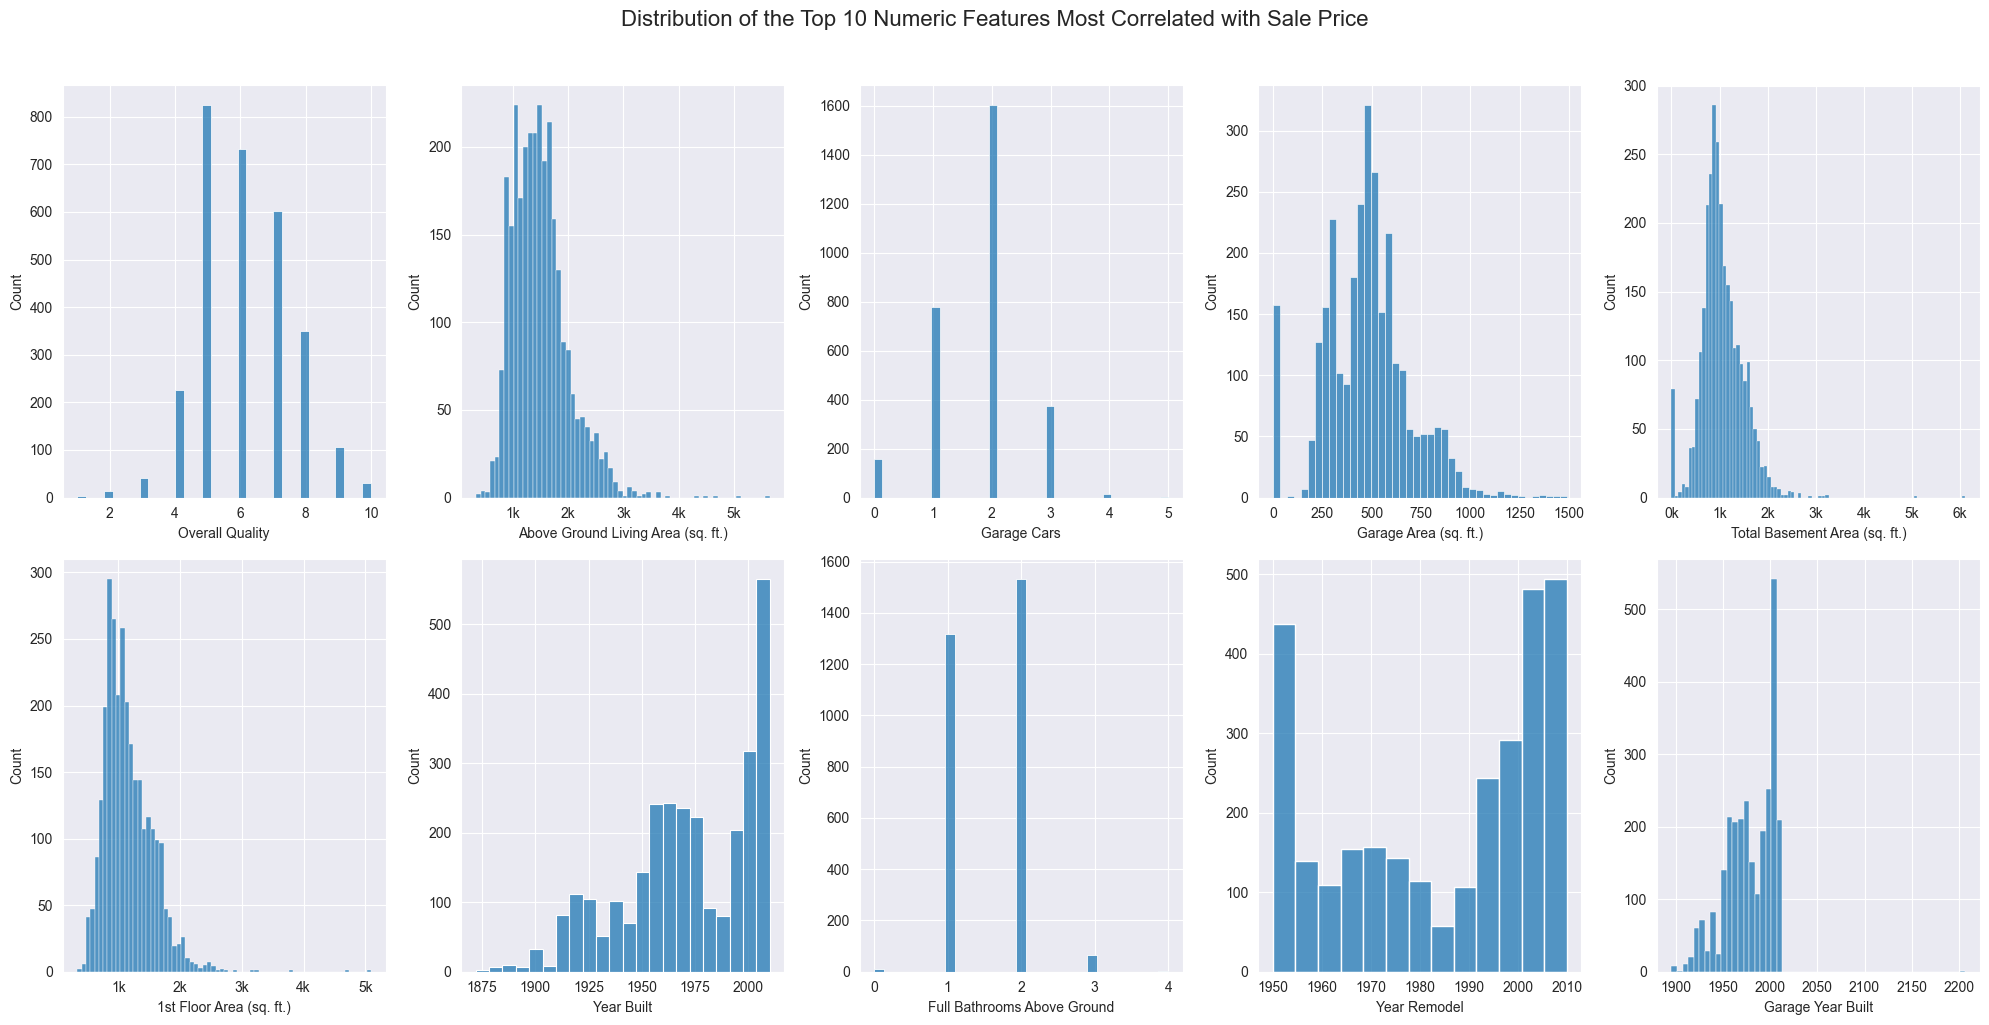

In [65]:
top_numeric_features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Garage Area",
    "Total Bsmt SF",
    "1st Flr SF",
    "Year Built",
    "Full Bath",
    "Year Remod/Add",
    "Garage Yr Blt"
]

sqft_features = [
    "Gr Liv Area",
    "Total Bsmt SF", 
    "1st Flr SF"
]

plot_numeric_distributions(
    df=housing_df,
    features=top_numeric_features,
    n_cols=5,
    figsize=(20, 10),
    k_format_cols=sqft_features,
    title="Distribution of the Top 10 Numeric Features Most Correlated with Sale Price"
)

Выводы:

* `Overall Quality`: Самое частое значение качества — 5, также много домов с оценками 6 и 7. Очень низкие и очень высокие оценки встречаются относительно редко. Показывает, что большинство домов имеют среднее или выше среднего общее качество.

* `Above Ground Living Area`: Распределение смещено вправо. Большинство домов имеют жилую площадь примерно от 1000 до 2000 sq ft. Но есть несколько выбросов с площадью выше 4 тысяч sq ft. 

* `Garage Cars`: Чаще всего гараж рассчитан на 2 машины. Можно предположить, что это идет из расчета по одной машине на человека в паре. 

* `Garage Area`: Большинство домов имеют площадь гаража примерно от 250 до 750 sq ft. Также есть достаточно большое количество домов без гаража. 

* `Total Basement Area`: Распределение смещено вправо. Большинство домов имеют площадь подвала примерно до 2 тысяч sq ft. Также есть около 80 домов без гаража. 

* `1st Floor Area`: Распределение также смещено вправо. Большинство значений находится примерно между 800 и 1800 sq ft. Небольшое количество домов имеет очень большую площадь первого этажа - возможно более дорогие дома. 

* `Year Built`: В датасете присутствуют дома с годами постройки от 1872 до 2010. Можно заметить тенденцию роста количества постройки домов с годами. Также, по относительному кол-ву построенных домов, можно увидеть три основных периода застройки: 1910-1925, 1950-1975, 1990-2010. 

* `Full Bathrooms Above Ground`: Чаще всего в домах 1 или 2 полноценные ванные комнаты. 

* `Year Remodel`: Значения распределены между 1950 и 2010 годами, но заметно много домов с годом ремонта около 1950 и после 1990–2000 годов. 

* `Garage Year Built`: Большинство гаражей построено примерно между 1950 и 2010 годами. Распределение похоже на `Year Built`, что логично, так как гараж часто строится вместе с домом. Также виден нереалистичный выброс - год постройки гаража в 2207 - скорее всего является ошибкой ввода данных. 

В данных обнаружено нереалистичное значение: `Garage Yr Blt = 2207`. Вероятнее всего, это ошибка ввода данных.

In [66]:
housing_df[housing_df['Garage Yr Blt'] > 2100]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2261,916384070,20,RL,68.0,8298,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,Timber,Norm,Norm,1Fam,1Story,8,5,2006,2007,Hip,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Gd,TA,Av,GLQ,583.0,Unf,0.0,963.0,1546.0,GasA,Ex,Y,SBrkr,1564,0,0,1564,0.0,0.0,2,0,2,1,Ex,6,Typ,1,Gd,Attchd,2207.0,RFn,2.0,502.0,TA,TA,Y,132,0,0,0,0,0,NaN,NaN,NaN,0,9,2007,New,Partial,267300


### Распределения 10 категориальных признаков с наибольшей разницей в медианной цене продажи

Так как категориальных признаков в датасете 43 штуки и для них нельзя посчитать обычную корреляцию с целевой переменной, было сделано решение просмотреть распределения тех категориальных переменных, у которых наибольшая разница в медианной цене продажи в зависимости от значения. 

In [67]:
cat_importance_df = get_categorical_importance(
    df=housing_df,
    categorical_cols=object_cols,
    min_count=10 # чтобы не учитывать подкатегории, где домов меньше 10
)

cat_importance_df.head(15)

,Variable,Unique values,Useful categories,Median SalePrice range
18,Exter Qual,4,4,285967.0
8,Neighborhood,28,25,230750.0
30,Kitchen Qual,5,4,217874.0
21,Bsmt Qual,5,4,217500.0
32,Fireplace Qu,5,5,184500.0
42,Sale Condition,6,6,140000.0
0,MS Zoning,7,5,131000.0
15,Exterior 1st,16,10,130000.0
33,Garage Type,6,6,127600.0
16,Exterior 2nd,17,12,127500.0


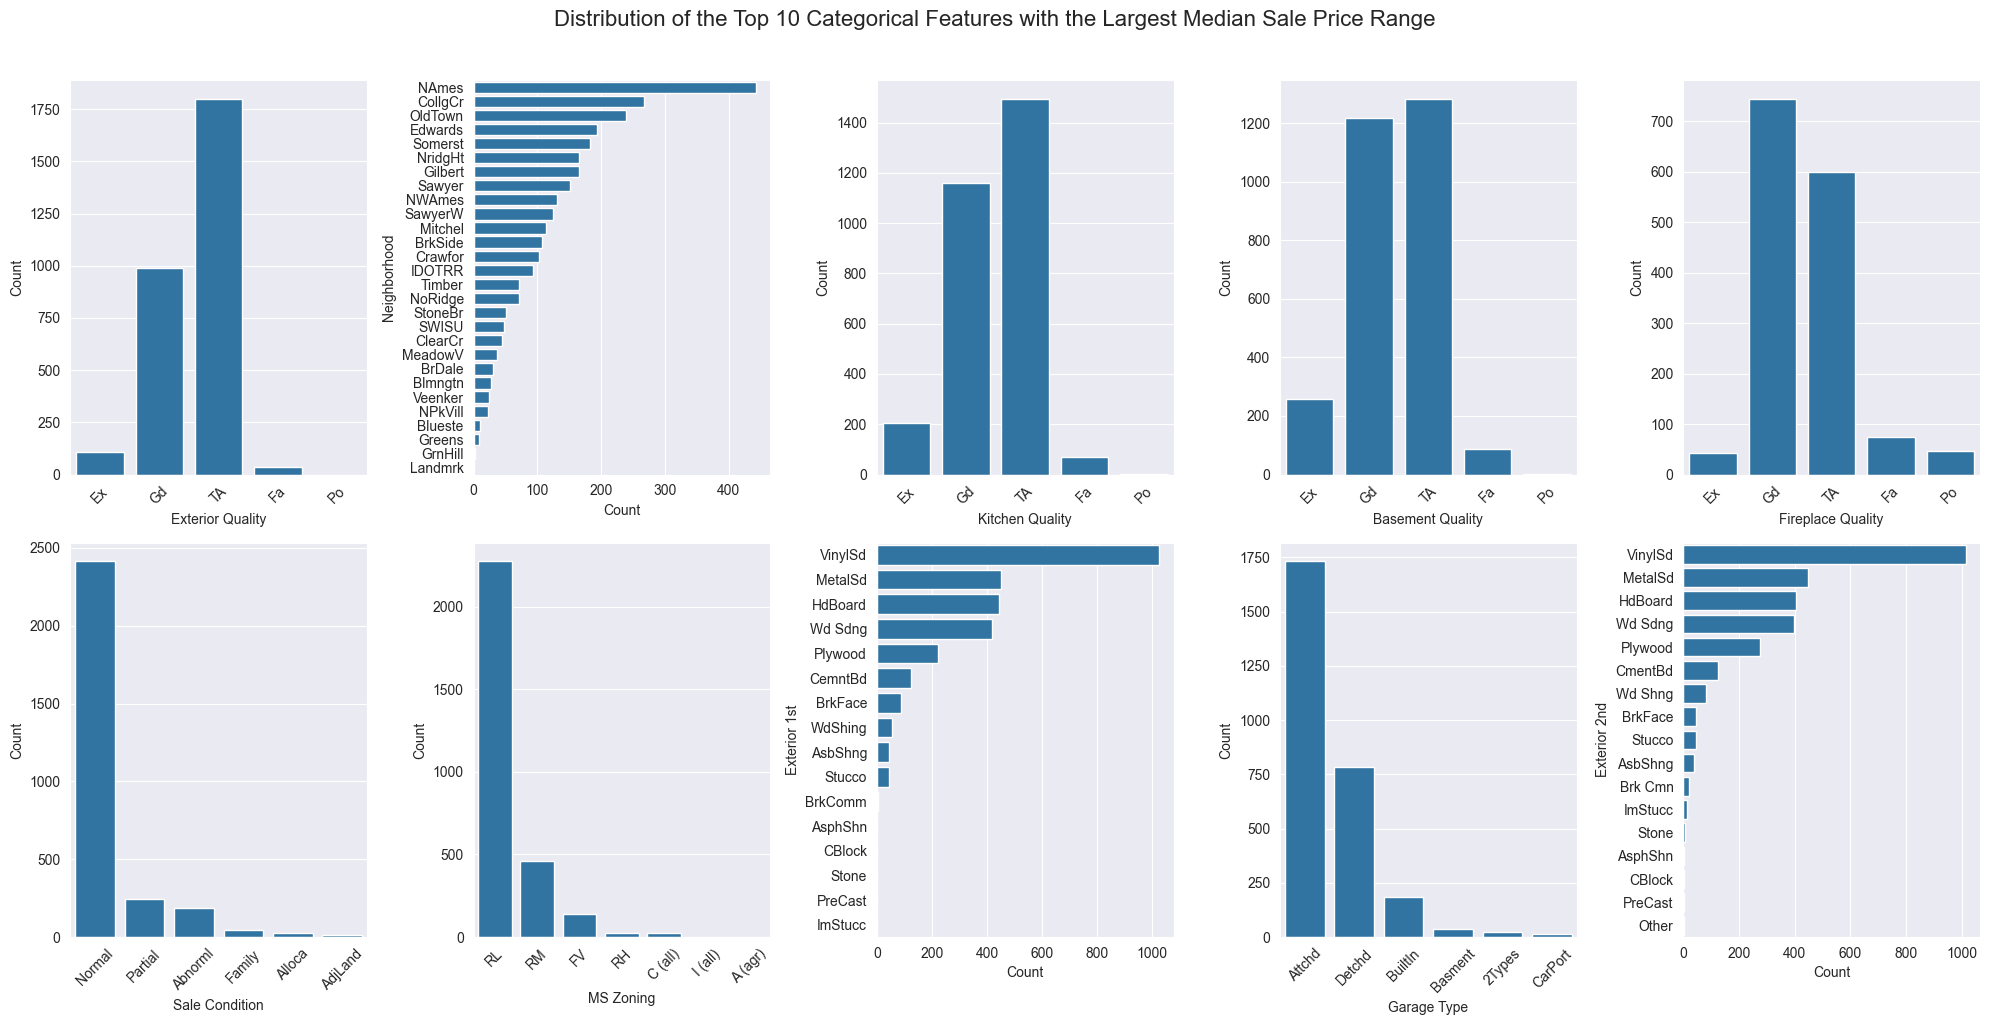

In [68]:
quality_order = ["Ex", "Gd", "TA", "Fa", "Po"]

top_cat_features = [
    "Exter Qual",
    "Neighborhood",
    "Kitchen Qual",
    "Bsmt Qual",
    "Fireplace Qu",
    "Sale Condition",
    "MS Zoning",
    "Exterior 1st",
    "Garage Type",
    "Exterior 2nd"
]

orders = {
    "Exter Qual": quality_order,
    "Kitchen Qual": quality_order,
    "Bsmt Qual": quality_order,
    "Fireplace Qu": quality_order
}

horizontal_cols = [
    "Neighborhood",
    "Exterior 1st",
    "Exterior 2nd"
]

plot_categorical_counts(
    df=housing_df,
    features=top_cat_features,
    n_cols=5,
    figsize=(20, 10),
    orders=orders,
    horizontal_cols=horizontal_cols,
    title="Distribution of the Top 10 Categorical Features with the Largest Median Sale Price Range"
)

Для справки, категории качества расшифровываются данным образом:

* `Ex` - Excellent

* `Gd` - Good

* `TA` - Typical/Average

* `Fa` - Fair

* `Po` - Poor

Выводы:

* `Exterior Quality`: В датасете преобладают дома со средним или хорошим состоянием внешней отделки. Очень мало с отличным или плохим состояниями. 

* `Neighborhood`: Распределение по районам неравномерное. Больше всего домов находится в районах `NAmes`, `CollgCr`, `OldTown`, `Edwards` и `Somerst`. 

* `Kitchen Quality`: Большинство домой имеют среднее или хорошее качество кухни. Категория `Ex` встречается заметно реже, а `Fa` и `Po` почти не представлены.

* `Basement Quality` & `Fireplace Quality`: Преобладающее количество подвалов и каминов оценено как хорошее или среднее. Тут нужно отметить, что в данном случае рассматриваются только те дома, которые **имеют** подвал и/или камин. 

* `Sale Condition`: Крайне высокий дисбаланс категорий. Преобладающие количество домов было продано в нормальном состоянии. 

* `MS Zoning`: Самая частая категория — `RL` (Residential Low Density, жилая зона с низкой плотностью застройки). Также заметно представлена категория `RM` (Residential Medium Density, жилая зона со средней плотностью застройки). Остальные категории встречаются редко.

* `Exterior 1st`: Самые распространенные материалы внешней отделки — `VinylSd` (виниловый сайдинг), `MetalSd` (металлический сайдинг), `HdBoard` (древесноволокнистые панели) и `Wd Sdng` (деревянный сайдинг).

* `Garage Type`: Самый частый тип гаража — `Attchd` (пристроенный к дому гараж). Также часто встречаются `Detchd` (отдельно стоящий гараж) и `BuiltIn` (гараж, встроенный в основную конструкцию дома).

* `Exterior 2nd`: Распределение похоже на `Exterior 1st` - чаще всего встречаются виниловый, металлический, древесноволокнистый и деревянный сайдинги. Редкие категории также присутствуют, но имеют малое количество наблюдений.

В целом, распределения категориальных признаков показывают, что многие переменные имеют сильный дисбаланс категорий.

### Визуализация отношений признаков с целевой переменной

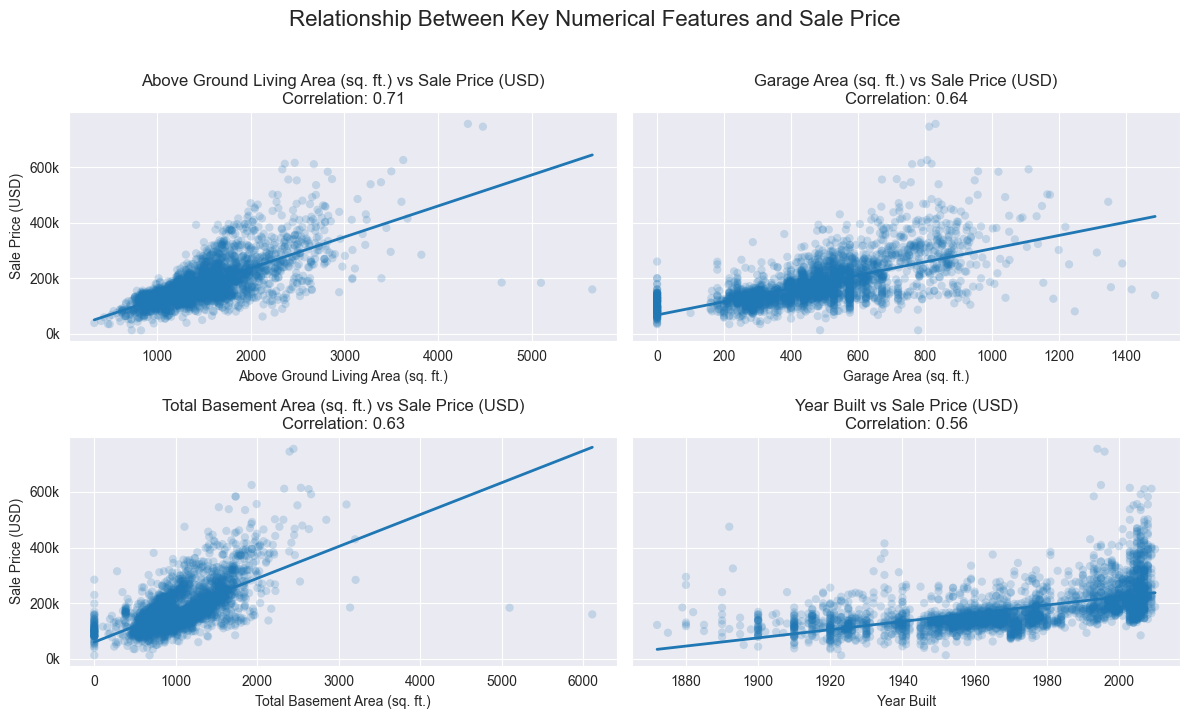

In [69]:
continuous_features = [
    "Gr Liv Area",
    "Garage Area",
    "Total Bsmt SF",
    "Year Built"
]

plot_numeric_vs_target(
    df=housing_df,
    features=continuous_features,
    n_cols=2,
    figsize=(12, 7)
)

Вывод: 

Все четыре числовых признака имеют положительную связь с `SalePrice`: при увеличении жилой площади, площади гаража, площади подвала и года постройки цена дома обычно растет. На графиках также видны отдельные выбросы.

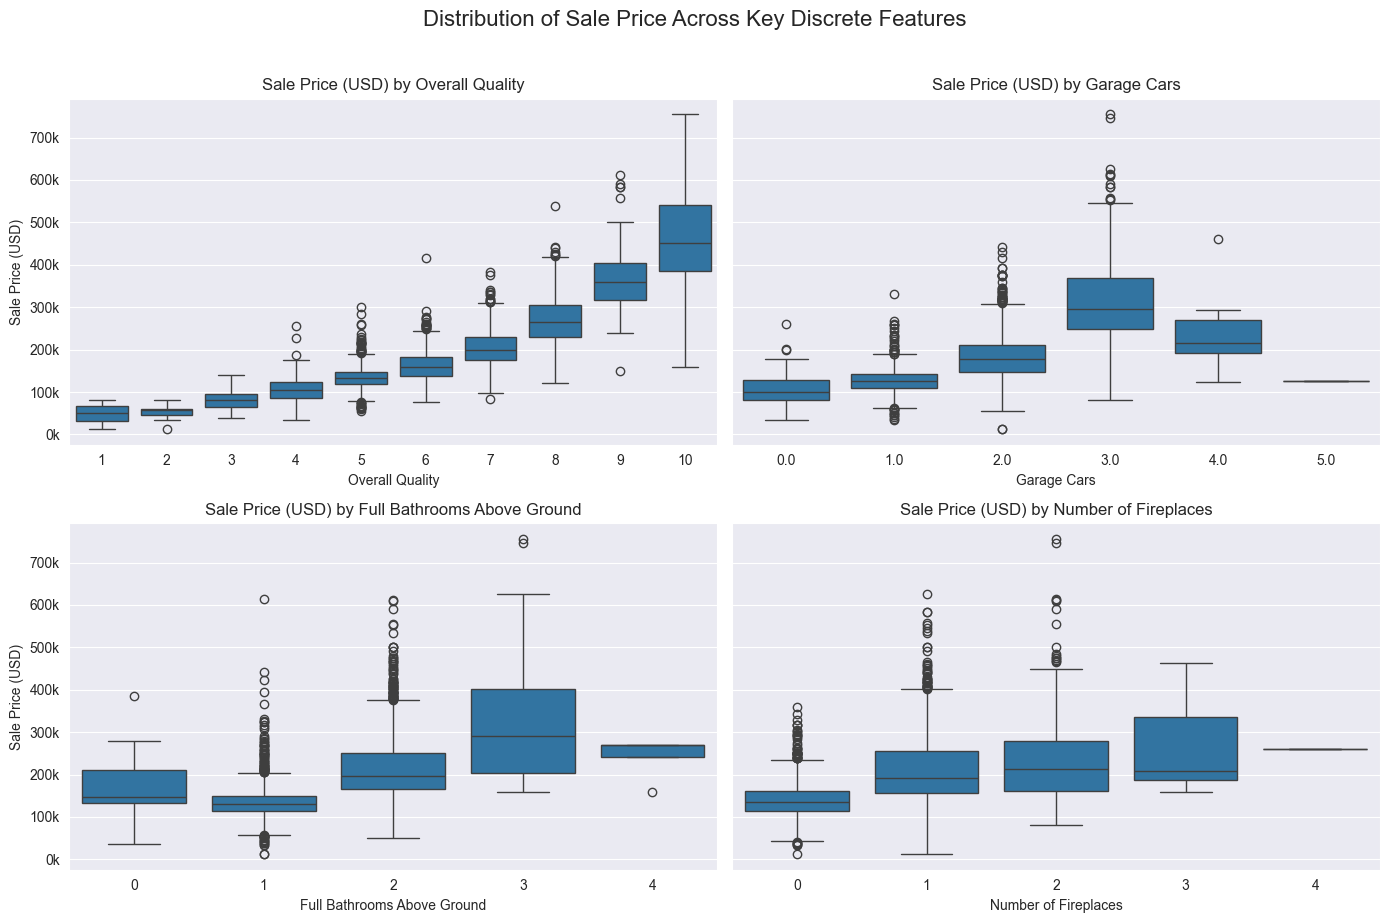

In [70]:
discrete_features = [
    "Overall Qual",
    "Garage Cars",
    "Full Bath",
    "Fireplaces"
]

plot_boxplots_vs_target(
    df=housing_df,
    features=discrete_features,
    n_cols=2,
    figsize=(14, 9),
    title="Distribution of Sale Price Across Key Discrete Features"
)

Выводы:

* `Overall Quality`: Можно заметить, что ростом оценки качества также поднимается медианная стоимость недвижимости. То есть, медианная цена недвижимости с оценкой 8 значительно выше, чем медианная цена недвижимости с оценкой 3 (разница около ~170 тысяч долларов). Также видно, что при повышении оценки качества обычно увеличивается вариативность в стоимости, особенно для категорий 8–10. Исключением является категория 9. В некоторых категориях присутствует достаточно много выбросов, особенно в категории 5, что логично, так как это одна из самых частых категорий в датасете.

* `Garage Cars`: Медианная цена жилья увеличивается вместе с количеством машиномест в гараже до категории 3. После этого медианная цена снижается, однако это может быть связано с тем, что домов с гаражом на 4–5 машин в датасете значительно меньше - эти категории могут быть менее репрезентативными.

* `Full Bathrooms Above Ground`: В целом, медианная цена недвижимости растёт с увеличением количества полноценных ванных комнат над уровнем земли. Дома с 2 и 3 ванными обычно стоят заметно дороже, чем дома с 1 ванной. При этом категория 1 содержит много выбросов, то есть среди домов с одной ванной также встречаются дорогие объекты.

* `Number of Fireplaces`: Наличие камина связано с более высокой стоимостью недвижимости. Дома без камина имеют самую низкую медианную цену, а при наличии 1–3 каминов медианная цена постепенно увеличивается. Также в категориях 1 и 2 присутствует много выбросов, что может говорить о наличии дорогих домов с небольшим количеством каминов.


### Визуализации отношений между признаками

Для визуализации отношений между ключевыми признаками была выбрана pair plot визуализация, так как она позволяет оценить взаимосвязи одновременно, на одной картинке. Были также добавлены категории цены для более легкого восприятия. 

По диагонали отображены распределения отдельных признаков по ценовым категориям. В данном разделе они подробно не рассматриваются, так как распределения признаков уже были проанализированы ранее.

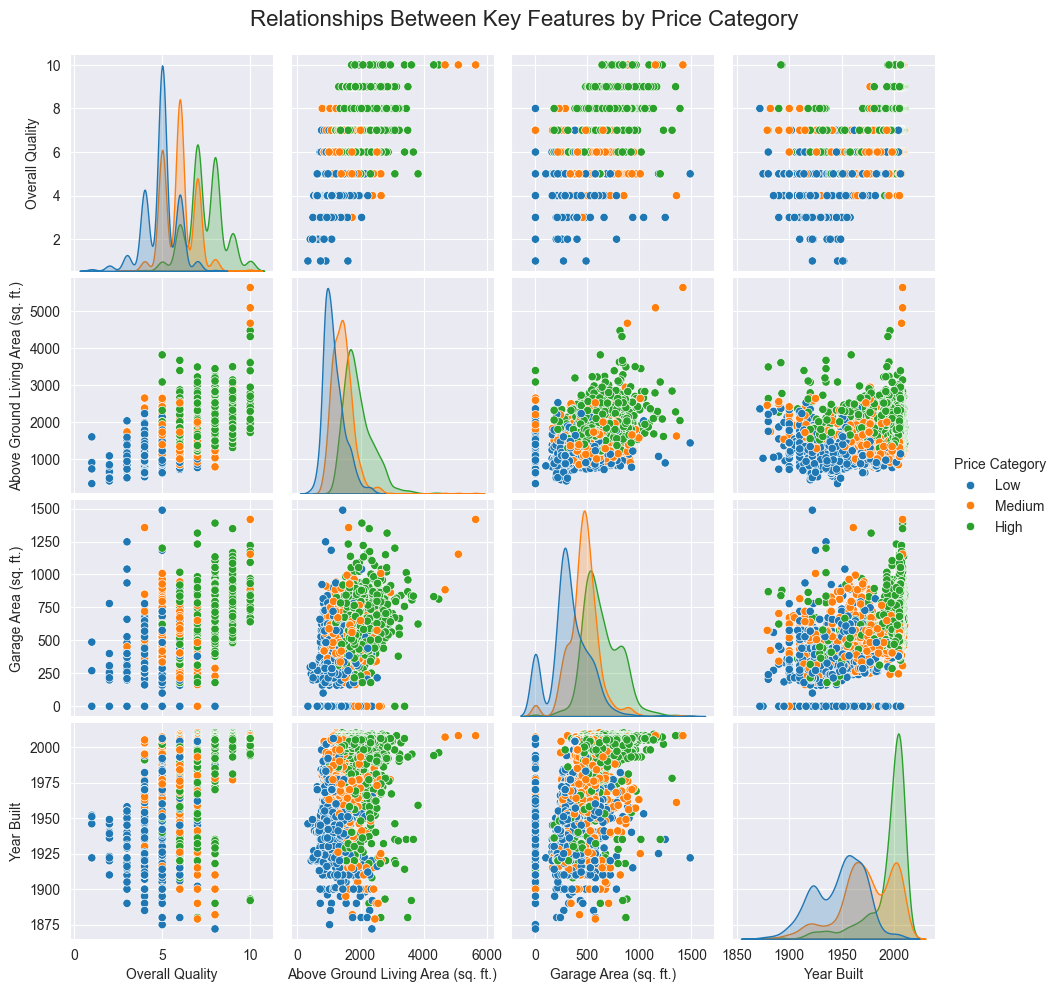

In [71]:
pairplot_features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Area",
    "Year Built"
]

plot_pairplot_by_price_category(
    df=housing_df,
    features=pairplot_features,
    q=3,
    labels=["Low", "Medium", "High"]
)

Чтобы не рассматривать каждый из 12 графиков взаимосвязи отдельно, тут будут приведены только интересные наблюдения. 

Выводы:

* Между Above Ground Living Area и Garage Area прослеживается положительная связь: у домов с большей жилой площадью часто больше и площадь гаража. Однако зависимость не идеально линейная, так как есть дома с большой жилой площадью, но сравнительно небольшим гаражом, и наоборот.

* Между Year Built и Overall Quality видна связь: более новые дома чаще имеют более высокую оценку качества. Является достаточно логичным - старые дома могут иметь в себи некоторые ветхости, которые будут ухудшать общую оценку качества. 

* Между Overall Quality и Above Ground Living Area прослеживается положительная связь: дома с более высокой оценкой качества чаще имеют большую жилую площадь. 

Данный график был сделан из интереса, так как показывает распределение оценочных суждений по районам. 

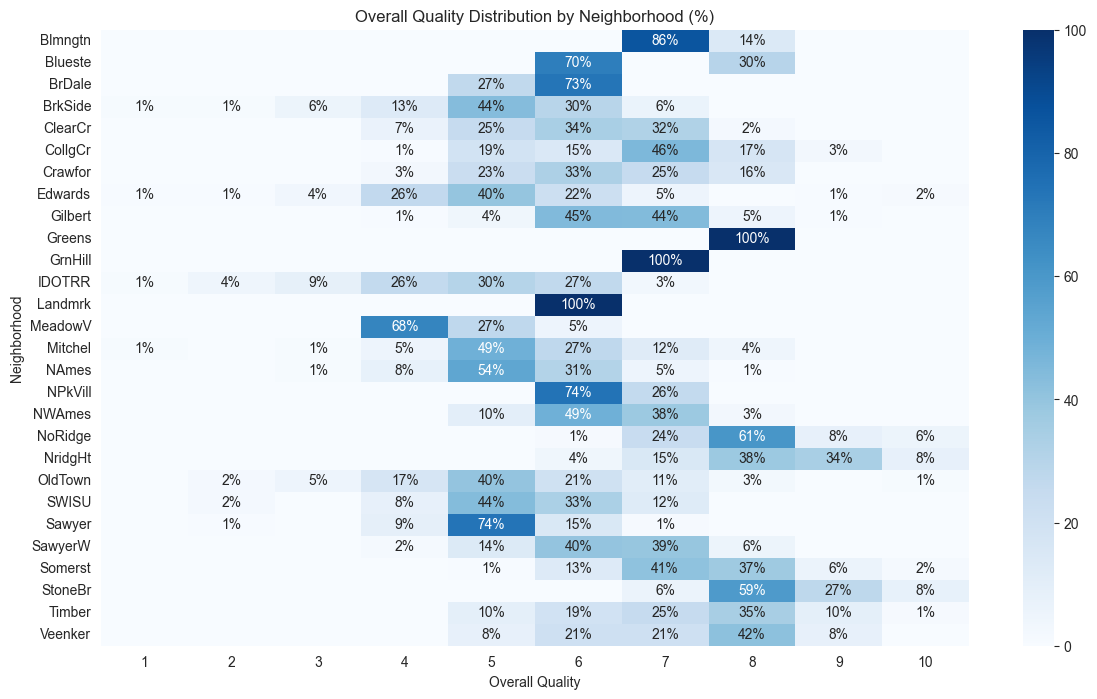

In [72]:
neighborhood_quality_table = plot_percentage_crosstab_heatmap(
    df=housing_df,
    row_col="Neighborhood",
    col_col="Overall Qual",
    figsize=(14, 8),
    cmap="Blues",
    title="Overall Quality Distribution by Neighborhood (%)"
)


Выводы:

* Первое, что бросается в глаза, - в нескольких районах все дома имеют одну и ту же оценку качества. Например, в GrnHill все дома имеют оценку 7, в Landmrk - 6, а в Greens - 8.

* В большинстве районов основная доля домов сосредоточена в диапазоне оценок от 4 до 8.

* В некоторых районах встречаются дома с более низкими оценками качества, например BrkSide, Edwards, IDOTRR, Mitchel, OldTown, SWISU и Sawyer. Интересно, что в этих районах доля домов с оценкой 7 и выше обычно небольшая или вовсе отсутствует.

* В то же время есть районы, где преобладают дома с более высокими оценками качества. Например, в NoRidge, NridgHt, StoneBr, Somerst, Timber и Veenker значительная часть домов имеет оценки 7–9, а домов с низкими оценками почти нет.


### Корреляционная матрица числовых признаков


такая, потому что если строить полную, то получается матрица 38 х 38 = 1444 значений

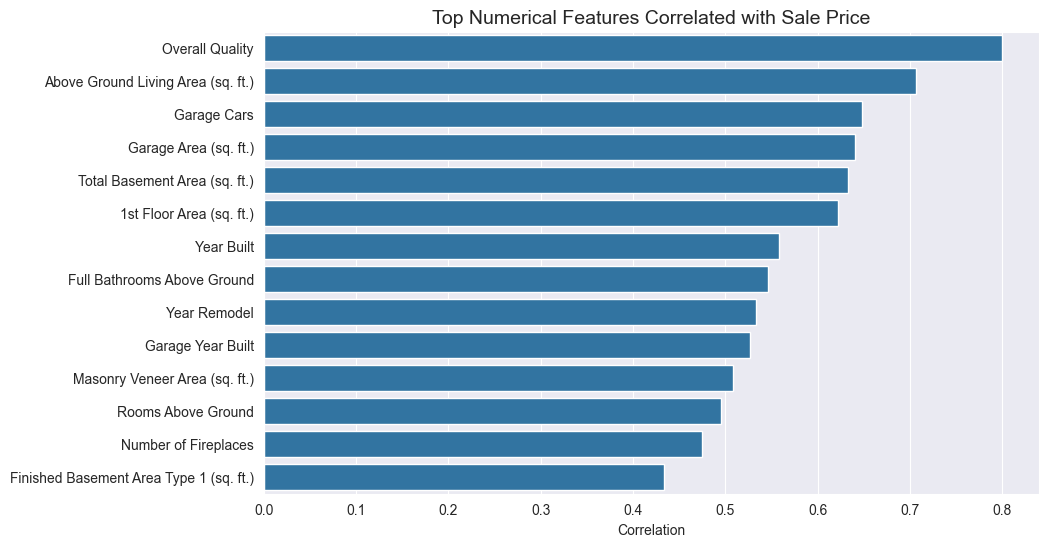

,Variable,Correlation
0,Overall Quality,0.799262
1,Above Ground Living Area (sq. ft.),0.706780
2,Garage Cars,0.647877
3,Garage Area (sq. ft.),0.640401
4,Total Basement Area (sq. ft.),0.632280
5,1st Floor Area (sq. ft.),0.621676
6,Year Built,0.558426
7,Full Bathrooms Above Ground,0.545604
8,Year Remodel,0.532974
9,Garage Year Built,0.526965


In [73]:
plot_top_correlations(housing_df)

правильно ли?

### Анализ выбросов и общего качества данных

**Проверка процентного содержания выбросов в значениях численных признаков**

In [74]:
outlier_summary = get_iqr_outliers(
    df=housing_df,
    cols=num_cols,
    factor=1.5
)

outlier_summary[outlier_summary['Outlier Count'] > 0]

,Variable,Lower Bound,Upper Bound,Outlier Count,Outlier %
30,Enclosed Porch,0.000,0.000,459,15.67
10,BsmtFin SF 2,0.000,0.000,351,11.98
32,Screen Porch,0.000,0.000,256,8.74
5,Overall Cond,3.500,7.500,252,8.60
1,MS SubClass,-55.000,145.000,208,7.10
8,Mas Vnr Area,-246.000,410.000,200,6.83
2,Lot Frontage,25.000,113.000,187,6.38
18,Bsmt Half Bath,0.000,0.000,175,5.97
29,Open Porch SF,-105.000,175.000,159,5.43
37,SalePrice,3500.000,339500.000,137,4.68


33 из 38 численных признаков содержат варьирующееся количество выбросов. 

Больше 10% содержат:

* `Enclosed Porch` - Плошадь закрытой веранды: 15%

* `BsmtFin SF 2` - Площадь первой отделанной зоны подвала: 11.98%

**Проверка нереалистичных значений для колонок с годами**

На всякий случай, так как была ошибка ввода для года постройки гаража. 

In [75]:
year_cols = [
    "Year Built",
    "Year Remod/Add",
    "Garage Yr Blt",
    "Yr Sold"
]

unusual_years = get_unusual_year_values(
    df=housing_df,
    year_cols=year_cols,
    current_year=2026
)

unusual_years

,Variable,Unusual Count,Unusual Values
0,Year Built,0,[]
1,Year Remod/Add,0,[]
2,Garage Yr Blt,1,[2207.0]
3,Yr Sold,0,[]


Судя по всему, это была одна такая ошибка.

**Проверка на негативные значения для численных признаков**

In [76]:
negative_values = get_negative_values(
    df=housing_df,
    cols=num_cols
)

negative_values[negative_values["Negative Count"] > 0]

,Variable,Negative Count


Негативных значений не наблюдается. 

**Проверка уникальных значений в категориальных признаках**

In [77]:
get_unique_values(housing_df, object_cols)

{'MS Zoning': ['A (agr)', 'C (all)', 'FV', 'I (all)', 'RH', 'RL', 'RM'],
 'Street': ['Grvl', 'Pave'],
 'Alley': ['Grvl', 'Pave'],
 'Lot Shape': ['IR1', 'IR2', 'IR3', 'Reg'],
 'Land Contour': ['Bnk', 'HLS', 'Low', 'Lvl'],
 'Utilities': ['AllPub', 'NoSeWa', 'NoSewr'],
 'Lot Config': ['Corner', 'CulDSac', 'FR2', 'FR3', 'Inside'],
 'Land Slope': ['Gtl', 'Mod', 'Sev'],
 'Neighborhood': ['Blmngtn',
  'Blueste',
  'BrDale',
  'BrkSide',
  'ClearCr',
  'CollgCr',
  'Crawfor',
  'Edwards',
  'Gilbert',
  'Greens',
  'GrnHill',
  'IDOTRR',
  'Landmrk',
  'MeadowV',
  'Mitchel',
  'NAmes',
  'NPkVill',
  'NWAmes',
  'NoRidge',
  'NridgHt',
  'OldTown',
  'SWISU',
  'Sawyer',
  'SawyerW',
  'Somerst',
  'StoneBr',
  'Timber',
  'Veenker'],
 'Condition 1': ['Artery',
  'Feedr',
  'Norm',
  'PosA',
  'PosN',
  'RRAe',
  'RRAn',
  'RRNe',
  'RRNn'],
 'Condition 2': ['Artery',
  'Feedr',
  'Norm',
  'PosA',
  'PosN',
  'RRAe',
  'RRAn',
  'RRNn'],
 'Bldg Type': ['1Fam', '2fmCon', 'Duplex', 'Twnhs', 'T

По визуальному просмотру, возможных опечаток и/или лишних пробелов не было найдено. 

### Анализ пропущенных значений


В самом начале EDA, в процессе просмотра пропущенных значений, была замечена определенная особенность - многие колонки, в которых находились пропущенные значения, относились к похожим вещам - Fireplace, Garage, Basement, etc. Что привело к идее того, что они могут быть взаимосвязанными. 

После большей инспекции значений, стало понятно, что во многих случаях пропущенные значения имеют смысл - допустим, если пропущенно значение для Fireplace Quality, то вполне возможно, что оно так, потому что конкретно в этом доме не было камина. Аналогичная логика применима к признакам, связанным с гаражом, подвалом и другими дополнительными характеристиками дома.

Такой вид пропусков можно рассматривать как структурные пропуски, которые невозможно и было бы неправильно заполнять стандартными способами (медиана, среднее, мода), потому что отсутствие значение само по себе несет информацию о доме. ЭТо MNAR пропуски. 


Таким образом, признаки с пропущенными значениеми можно разделить на два типа:
* Признаки с структурными пропусками - пропуски, которые имеют логическое объяснение. Например, отсутствие значения в признаке качества камина может означать отсутствие самого камина. Также могут содержать некоторый процент пропусков, который не объясняется структурно.

* Признаки с неструктурными (случайными) пропусками - пропуски, которые не имеют очевидного смыслового объяснения. Можно подставлять, как обычно. 


**Структурные пропуски**

1. **Basement variables**
   - `Bsmt Qual`
   - `Bsmt Cond`
   - `Bsmt Exposure`
   - `BsmtFin Type 1`
   - `BsmtFin Type 2`
   - `BsmtFin SF 1`
   - `BsmtFin SF 2`
   - `Bsmt Unf SF`
   - `Total Bsmt SF`
   - `Bsmt Full Bath`
   - `Bsmt Half Bath`

2. **Garage variables**
   - `Garage Type`
   - `Garage Yr Blt`
   - `Garage Finish`
   - `Garage Qual`
   - `Garage Cond`
   - `Garage Cars`
   - `Garage Area`

3. **Fireplace quality**
   - `Fireplace Qu`

4. **Masonry veneer variables**
   - `Mas Vnr Type`
   - `Mas Vnr Area`

5. **Pool quality**
   - `Pool QC`

6. **Fence quality**
   - `Fence`

7. **Alley access**
   - `Alley`

**Подсчёт доли пропущенных значений, объясняемых отсутствием соответствующего объекта**

In [78]:
conditions = get_structural_missingness_conditions(housing_df)

missingness_explanation_df = get_missingness_explanation_table(
    df=housing_df,
    conditions=conditions,
    missingness_groups=missingness_groups
)

missingness_explanation_df

,Variable,Missing Count,Explained Count,Explained %,Unexplained Count,Explanation
19,Mas Vnr Type,1775,1768,99.61,7,No masonry veneer
2,Bsmt Exposure,83,80,96.39,3,No basement
4,BsmtFin Type 2,81,80,98.77,1,No basement
12,Garage Yr Blt,159,158,99.37,1,No garage
13,Garage Finish,159,158,99.37,1,No garage
14,Garage Qual,159,158,99.37,1,No garage
15,Garage Cond,159,158,99.37,1,No garage
0,Bsmt Qual,80,80,100.00,0,No basement
1,Bsmt Cond,80,80,100.00,0,No basement
3,BsmtFin Type 1,80,80,100.00,0,No basement


Видно, что для 7 признаков присутствуют маленькое количество записей с случайными пропусками. 

**Временное решение: удалить строки, в структурных колонках которые есть необъясненные пропуски**

In [79]:
# TEMP SOLUTION

housing_df_clean = drop_unexplained_structural_missingness(
    df=housing_df,
    conditions=conditions,
    missingness_groups=missingness_groups
)

Before: (2930, 81)
After: (2918, 81)
Dropped rows: 12


**Неструктурные пропуски**

8. **Electrical system**
   - `Electrical`

9. **Lot frontage**
   - `Lot Frontage`

10. **Miscellaneous feature**
   - `Misc Feature`

**Подсчёт доли пропущенных значений, не имеющих структурного объяснения**

In [80]:
ordinary_missing_vars = [
    "Electrical",
    "Lot Frontage",
    "Misc Feature"
]

for col in ordinary_missing_vars:
    available_percentage = housing_df[col].notna().mean() * 100
    missing_percentage = housing_df[col].isna().mean() * 100

    print(f"{col}:")
    print(f"  Available: {available_percentage:.2f}%")
    print(f"  Missing: {missing_percentage:.2f}%")

Electrical:
  Available: 99.97%
  Missing: 0.03%
Lot Frontage:
  Available: 83.28%
  Missing: 16.72%
Misc Feature:
  Available: 3.62%
  Missing: 96.38%


## 4. Предобработка

* Обработка пропусков

* Кодирование категориальных переменных

* Масштабирование


**Подготовка данных: разделение**

In [81]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = housing_df.drop('SalePrice', axis=1)
y = housing_df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42
)

**Проверка признаков на утечку данных о целевой переменной**

Чтобы предотвратить утечку данных о целевой переменной требуется исключить из списка признаков те признаки, которые были бы недоступны на момент выполнения предсказания. Предварительно, в данном датасете такими признаками являются: идентификатор продажи, месяц продажи, год продажи, тип продажи, и условия продажи. 

Тип продажи описывает формат или юридический тип сделки. Возможные значения включают:

* WD — обычная продажа;

* CWD — оплата наличными;

* VWD — гарантийный акт с использованием VA-кредита;

* New — продажа нового дома;

* COD — продажа через судебного исполнителя / продажа имущества наследства;

* Con, ConLw, ConLI, ConLD — различные виды контрактной продажи;

Условия продажи описывают обстоятельства, при которых была совершена сделка. Возможные значения включают:

* Normal — обычная продажа;

* Abnorml — нестандартная продажа, например продажа изъятого за долги имущества, продажа по цене ниже остатка ипотечного долга или продажа имущества наследства;

* AdjLand — покупка прилегающего участка земли;

* Alloca — продажа, связанная с несколькими объектами недвижимости;

* Family — продажа между членами семьи;

* Partial — частичная продажа, часто связанная с новым строительством.


Эти признаки описывают не физические характеристики дома, а особенности самой сделки.

In [82]:
leakage_cols = [
    "PID",
    "Mo Sold",
    "Yr Sold",
    "Sale Type",
    "Sale Condition"
]

**Feature Engineering**

Так как в датасете уже достаточно много признаков, добавлю только один обобщенный признак на основе `Misc Feature`, чтобы дальше не увеличивать размерность данных.

In [83]:
X_train["Has Misc Feature"] = X_train["Misc Feature"].notna().astype(int) # есть ли лифт и так далее
X_test["Has Misc Feature"] = X_test["Misc Feature"].notna().astype(int)

**Dropping Values**

In [84]:
X_train, X_test = clean_before_preprocessing(
    X_train,
    X_test,
    leakage_cols
)

**Обработка пропусков: случайные** 

* Electrical Missing: 0.03% - Categorical

* Lot Frontage Missing: 16.72% - Numerical
  

In [85]:
print(housing_df['Lot Frontage'].skew())
get_iqr_outliers(housing_df, ['Lot Frontage'], 1.5)

1.499067354883421


,Variable,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Lot Frontage,25.0,113.0,187,6.38


In [86]:
housing_df['Electrical'].unique()

array(['SBrkr', 'FuseA', 'FuseF', 'FuseP', nan, 'Mix'], dtype=object)

Так как Lot Frontage имеет коэффицент ассиметрии > 1, и также ~6% выбросов, используется RobustScaler() и медиана.

Electrical будем заполнять по моде. 

In [87]:
ordinary_num_cols = [
    "Lot Frontage" 
]

ordinary_cat_cols = [
    "Electrical" # виды электрической проводки
]

ordinary_num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

ordinary_cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


**Обработка пропусков: структурные** 

24 признака

In [88]:
# списки с признаками вынесены в отдельный файл

structural_cat_ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("ordinal", OrdinalEncoder(categories=structural_cat_ordinal_categories))
])

structural_cat_nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown='ignore'))
])

structural_num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", RobustScaler())
])

**Кодирование и масштабирование**

49 признаков

In [89]:
# списки с признаками вынесены в отдельный файл

full_cat_ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # на всякий
    ("ordinal", OrdinalEncoder(categories=full_cat_ordinal_categories))
])

full_cat_nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # на всякий
    ("onehot", OneHotEncoder(handle_unknown='ignore'))
])

full_num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), # на всякий
    ("scaler", RobustScaler())
])


In [90]:
preprocessor = ColumnTransformer(
    transformers=[
        ## обычные пропуски
        ("ordinary_num", ordinary_num_transformer, ordinary_num_cols),
        ("ordinary_cat", ordinary_cat_transformer, ordinary_cat_cols),

        ## структурные пропуски
        ("structural_num", structural_num_transformer , structural_num_cols),
        ("structural_cat_ordinal", structural_cat_ordinal_transformer, structural_cat_ordinal_cols),
        ("structural_cat_nominal", structural_cat_nominal_transformer, structural_cat_nominal_cols),

        ## оставшиеся данные
        ("full_num", full_num_transformer, full_num_cols),
        ("full_cat_ordinal", full_cat_ordinal_transformer, full_cat_ordinal_cols),
        ("full_cat_nominal", full_cat_nominal_transformer, full_cat_nominal_cols)  
    ],
    remainder="drop"
)

## 5. Моделирование

* Модель 1: Linear Regression

* Модель 2: Decision Tree

* Модель 3: Random Forest

* Модель 4: Gradient Boosting

* Модель 5: MLP

MLP предоставлен в следующей секции ноутбука.



**Пайплайны моделей**

Linear regression

Linear regression + KSelect

Decision Tree

Random Forest

Random Forest + KSelect

Gradient Boosting

Gradient Boosting + KSelect

XGBoost

XGBoost + KSelect


In [91]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from xgboost import XGBRegressor

models = build_regression_models(
    preprocessor=preprocessor,
    k=100,
    random_state=42
)

**Шаг для просмотра датасета, который уже прошел препроцессинг**

In [92]:
linreg_model = models["Linear Regression"]

X_processed = linreg_model.named_steps["preprocessor"].fit_transform(X_train)

feature_names = linreg_model.named_steps["preprocessor"].get_feature_names_out()

X_processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names,
    index=X_train.index
)

X_processed_df.head()

,ordinary_num__Lot Frontage,ordinary_cat__Electrical_FuseA,ordinary_cat__Electrical_FuseF,ordinary_cat__Electrical_FuseP,ordinary_cat__Electrical_Mix,ordinary_cat__Electrical_SBrkr,structural_num__Garage Yr Blt,structural_num__BsmtFin SF 1,structural_num__BsmtFin SF 2,structural_num__Bsmt Unf SF,structural_num__Total Bsmt SF,structural_num__Bsmt Full Bath,structural_num__Bsmt Half Bath,structural_num__Garage Cars,structural_num__Garage Area,structural_num__Mas Vnr Area,structural_cat_ordinal__Bsmt Exposure,structural_cat_ordinal__BsmtFin Type 2,structural_cat_ordinal__Garage Finish,structural_cat_ordinal__Garage Qual,structural_cat_ordinal__Garage Cond,structural_cat_ordinal__Bsmt Qual,structural_cat_ordinal__Bsmt Cond,structural_cat_ordinal__BsmtFin Type 1,structural_cat_ordinal__Fireplace Qu,structural_cat_ordinal__Pool QC,structural_cat_ordinal__Fence,structural_cat_ordinal__Alley,structural_cat_nominal__Mas Vnr Type_BrkCmn,structural_cat_nominal__Mas Vnr Type_BrkFace,structural_cat_nominal__Mas Vnr Type_CBlock,structural_cat_nominal__Mas Vnr Type_None,structural_cat_nominal__Mas Vnr Type_Stone,structural_cat_nominal__Garage Type_2Types,structural_cat_nominal__Garage Type_Attchd,structural_cat_nominal__Garage Type_Basment,structural_cat_nominal__Garage Type_BuiltIn,structural_cat_nominal__Garage Type_CarPort,structural_cat_nominal__Garage Type_Detchd,structural_cat_nominal__Garage Type_None,full_num__Lot Area,full_num__Year Built,full_num__Year Remod/Add,full_num__1st Flr SF,full_num__2nd Flr SF,full_num__Low Qual Fin SF,full_num__Gr Liv Area,full_num__Full Bath,full_num__Half Bath,full_num__Bedroom AbvGr,full_num__Kitchen AbvGr,full_num__TotRms AbvGrd,full_num__Fireplaces,full_num__Wood Deck SF,full_num__Open Porch SF,full_num__Enclosed Porch,full_num__3Ssn Porch,full_num__Screen Porch,full_num__Pool Area,full_cat_ordinal__Lot Shape,full_cat_ordinal__Utilities,full_cat_ordinal__Land Slope,full_cat_ordinal__Overall Qual,full_cat_ordinal__Overall Cond,full_cat_ordinal__Exter Qual,full_cat_ordinal__Exter Cond,full_cat_ordinal__Heating QC,full_cat_ordinal__Kitchen Qual,full_cat_ordinal__Functional,full_cat_ordinal__Paved Drive,full_cat_nominal__MS SubClass_20,full_cat_nominal__MS SubClass_30,full_cat_nominal__MS SubClass_40,full_cat_nominal__MS SubClass_45,full_cat_nominal__MS SubClass_50,full_cat_nominal__MS SubClass_60,full_cat_nominal__MS SubClass_70,full_cat_nominal__MS SubClass_75,full_cat_nominal__MS SubClass_80,full_cat_nominal__MS SubClass_85,full_cat_nominal__MS SubClass_90,full_cat_nominal__MS SubClass_120,full_cat_nominal__MS SubClass_150,full_cat_nominal__MS SubClass_160,full_cat_nominal__MS SubClass_180,full_cat_nominal__MS SubClass_190,full_cat_nominal__MS Zoning_A (agr),full_cat_nominal__MS Zoning_C (all),full_cat_nominal__MS Zoning_FV,full_cat_nominal__MS Zoning_I (all),full_cat_nominal__MS Zoning_RH,full_cat_nominal__MS Zoning_RL,full_cat_nominal__MS Zoning_RM,full_cat_nominal__Street_Grvl,full_cat_nominal__Street_Pave,full_cat_nominal__Land Contour_Bnk,full_cat_nominal__Land Contour_HLS,full_cat_nominal__Land Contour_Low,full_cat_nominal__Land Contour_Lvl,full_cat_nominal__Lot Config_Corner,full_cat_nominal__Lot Config_CulDSac,full_cat_nominal__Lot Config_FR2,full_cat_nominal__Lot Config_FR3,full_cat_nominal__Lot Config_Inside,full_cat_nominal__Neighborhood_Blmngtn,full_cat_nominal__Neighborhood_Blueste,full_cat_nominal__Neighborhood_BrDale,full_cat_nominal__Neighborhood_BrkSide,full_cat_nominal__Neighborhood_ClearCr,full_cat_nominal__Neighborhood_CollgCr,full_cat_nominal__Neighborhood_Crawfor,full_cat_nominal__Neighborhood_Edwards,full_cat_nominal__Neighborhood_Gilbert,full_cat_nominal__Neighborhood_Greens,full_cat_nominal__Neighborhood_GrnHill,full_cat_nominal__Neighborhood_IDOTRR,full_cat_nominal__Neighborhood_Landmrk,full_cat_nominal__Neighborhood_MeadowV,full_cat_nominal__Neighborhood_Mitchel,full_cat_nominal__Neighborhood_NAmes,full_cat_nominal__Neighborhood_NPkVill,full_cat_nominal__Neighborhood_NWAmes

## 6. Оценка и сравнение

**Запуск поиска гиперпараметров**

In [93]:
results = run_regression_searches(
    models=models,
    param_distributions=param_distributions,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_test,
    y_valid=y_test,
    cv=cv,
    n_iters=n_iters
)



Running search for: Linear Regression

Linear Regression
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Best CV RMSE: 29906.719063230314
Best CV MAE: 17763.126157618433
Best CV R2: 0.8374735688906718

Best parameters:
{'model__fit_intercept': False}

Validation MAE: 18294.5457679714
Validation RMSE: 30762.69600840368
Validation R2: 0.8819659734047502

Running search for: Linear Regression + SelectKBest

Linear Regression + SelectKBest
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV RMSE: 30357.713250389636
Best CV MAE: 18202.038545026928
Best CV R2: 0.8339471866482088

Best parameters:
{'model__fit_intercept': False, 'select__k': 137}

Validation MAE: 19131.19836716279
Validation RMSE: 31112.130259525104
Validation R2: 0.879269240717085

Running search for: Decision Tree

Decision Tree
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV RMSE: 33889.2211242948
Best CV MAE: 22710.190150033035
Best CV R2: 0.8051303367732674

Best pa

**Вывод сводной таблицы**

In [94]:
summary_df = make_model_summary(results)

display(summary_df)

,model_name,best_cv_mae,best_cv_rmse,best_cv_r2,train_mae,valid_mae,train_rmse,valid_rmse,train_r2,valid_r2,best_params
6,Gradient Boosting + SelectKBest,14827.791812,24363.327990,0.893668,10760.594402,15025.357369,14862.559459,23861.337195,0.962848,0.928985,"{'model__learning_rate': 0.0706539497489318, '..."
5,Gradient Boosting,14272.714386,23915.615428,0.898175,9381.814509,14898.623648,13177.721032,25022.693518,0.970794,0.921904,"{'model__learning_rate': 0.05048762470240494, ..."
7,XGBoost,14074.759766,23923.792187,0.897086,9212.269531,14705.042969,12836.678698,25162.781404,0.972286,0.921028,{'model__colsample_bytree': 0.6968639753109703...
8,XGBoost + SelectKBest,14453.777344,24070.529297,0.897564,5481.434082,14829.520508,7371.990776,25552.160300,0.990860,0.918564,{'model__colsample_bytree': 0.8883759697008518...
3,Random Forest,15537.235908,25685.511012,0.884253,8061.620506,15184.798525,13923.252196,26859.122320,0.967396,0.910021,"{'model__bootstrap': True, 'model__criterion':..."
4,Random Forest + SelectKBest,15732.032257,25924.927899,0.882283,8197.753959,15343.635713,14530.508592,27007.333132,0.964490,0.909025,"{'model__bootstrap': True, 'model__criterion':..."
0,Linear Regression,17763.126158,29906.719063,0.837474,15058.109245,18294.545768,22974.756721,30762.696008,0.911224,0.881966,{'model__fit_intercept': False}
1,Linear Regression + SelectKBest,18202.038545,30357.713250,0.833947,16272.903014,19131.198367,25436.413521,31112.130260,0.891181,0.879269,"{'model__fit_intercept': False, 'select__k': 137}"
2,Decision Tree,22710.190150,33889.221124,0.805130,15446.611483,22545.027460,24102.787090,36015.176920,0.902292,0.838218,"{'model__criterion': 'squared_error', 'model__..."


**MLP**

In [95]:
import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


X_train_mlp = preprocessor.fit_transform(X_train)
X_test_mlp = preprocessor.transform(X_test)


mlp_model = Sequential([
    Dense(
        256,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    Dropout(0.1),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    Dropout(0.1),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),

    Dense(1)
])


mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)


history = mlp_model.fit(
    X_train_mlp,
    y_train,
    validation_data=(X_test_mlp, y_test),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

y_train_pred = mlp_model.predict(X_train_mlp).ravel()
y_valid_pred = mlp_model.predict(X_test_mlp).ravel()

train_mae = mean_absolute_error(y_train, y_train_pred)
valid_mae = mean_absolute_error(y_test, y_valid_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
valid_rmse = np.sqrt(mean_squared_error(y_test, y_valid_pred))

train_r2 = r2_score(y_train, y_train_pred)
valid_r2 = r2_score(y_test, y_valid_pred)

overfitting_coef = valid_rmse / train_rmse

print("Train MAE:", train_mae)
print("Validation MAE:", valid_mae)

print("Train RMSE:", train_rmse)
print("Validation RMSE:", valid_rmse)

print("Train R2:", train_r2)
print("Validation R2:", valid_r2)

print("Overfitting coefficient:", overfitting_coef)

Epoch 1/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 37833363456.0000 - mae: 178571.7969 - val_loss: 43972145152.0000 - val_mae: 189619.1875
Epoch 2/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37812068352.0000 - mae: 178516.0469 - val_loss: 43931348992.0000 - val_mae: 189521.0469
Epoch 3/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37756620800.0000 - mae: 178380.1250 - val_loss: 43835023360.0000 - val_mae: 189302.6875
Epoch 4/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37658296320.0000 - mae: 178138.1562 - val_loss: 43666718720.0000 - val_mae: 188914.3594
Epoch 5/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37503864832.0000 - mae: 177759.1250 - val_loss: 43412430848.0000 - val_mae: 188321.1875
Epoch 6/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37274796032.0000 - mae: 177215.3594 - val_loss: 43154788352.0000 - val_mae: 187811.6250
Epoch 7/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36956385280.0000 - mae: 176446.2500 - val_loss: 42723987456

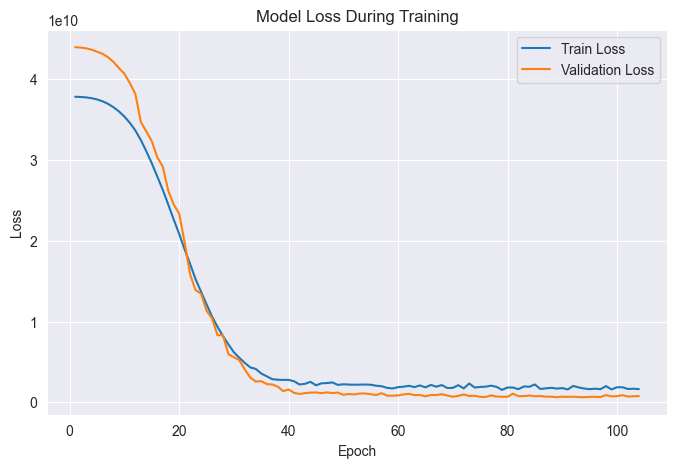

In [96]:
history_df = plot_training_history(history)

## 7. Анализ ошибок

**Таблица сравнения трех лучших ML моделей и MLP**

| Rank | Model                           | Train RMSE | Validation RMSE | Validation MAE | Validation R² | Overfitting Coefficient |
| ---: | ------------------------------- | ---------: | --------------: | -------------: | ------------: | ----------------------: |
|    1 | Gradient Boosting + SelectKBest |  14,862.56 |       23,861.34 |      15,025.36 |        0.9290 |                    1.61 |
|    2 | MLP                             |  21,023.03 |       24,945.46 |              — |        0.9224 |                    1.19 |
|    3 | Gradient Boosting               |  13,177.72 |       25,022.69 |      14,898.62 |        0.9219 |                    1.90 |
|    4 | XGBoost                         |  12,836.68 |       25,162.78 |      14,705.04 |        0.9210 |                    1.96 |
|    5 | XGBoost + SelectKBest           |   7,371.99 |       25,552.16 |      14,829.52 |        0.9186 |                    3.47 |




По значению Validation RMSE лучшей моделью является Gradient Boosting + SelectKBest: она показала наименьшую ошибку на валидационной выборке — 23,861.34 и самый высокий Validation R² = 0.9290.

MLP немного уступает по качеству предсказаний (Validation RMSE = 24,945.46), но имеет самый низкий коэффициент переобучения — 1.19, поэтому выглядит наиболее стабильной.

Gradient Boosting и XGBoost показывают близкие результаты. XGBoost + SelectKBest имеет сильное переобучение: коэффициент 3.47.

**Feature Importance**

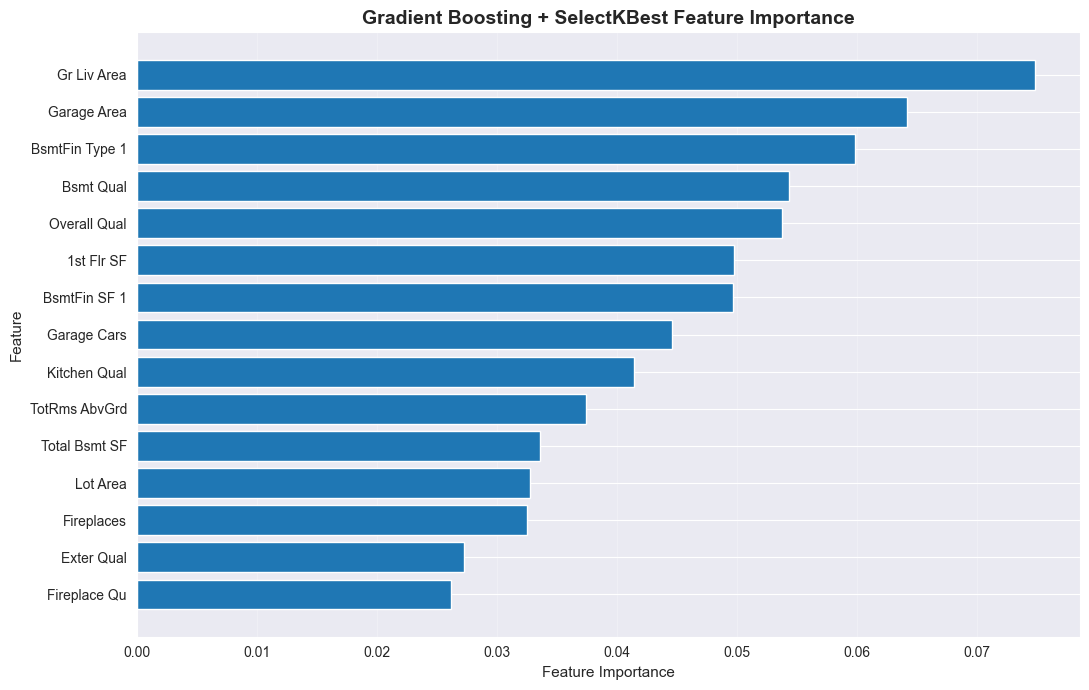

In [106]:
importance_df = plot_selected_model_feature_importance(
    model=results["Gradient Boosting + SelectKBest"]["best_model"],
    top_n=15,
    title="Gradient Boosting + SelectKBest Feature Importance"
)

Вывод: 

Модель Gradient Boosting + SelectKBest больше всего опирается на площадь жилого пространства над землей — Gr Liv Area. Также важны признаки гаража, подвала и общего качества дома: Garage Area, BsmtFin Type 1, Bsmt Qual, Overall Qual.

В целом, цена дома сильнее всего определяется размером, качеством и наличием функциональных зон — гаража, подвала, кухни и камина.

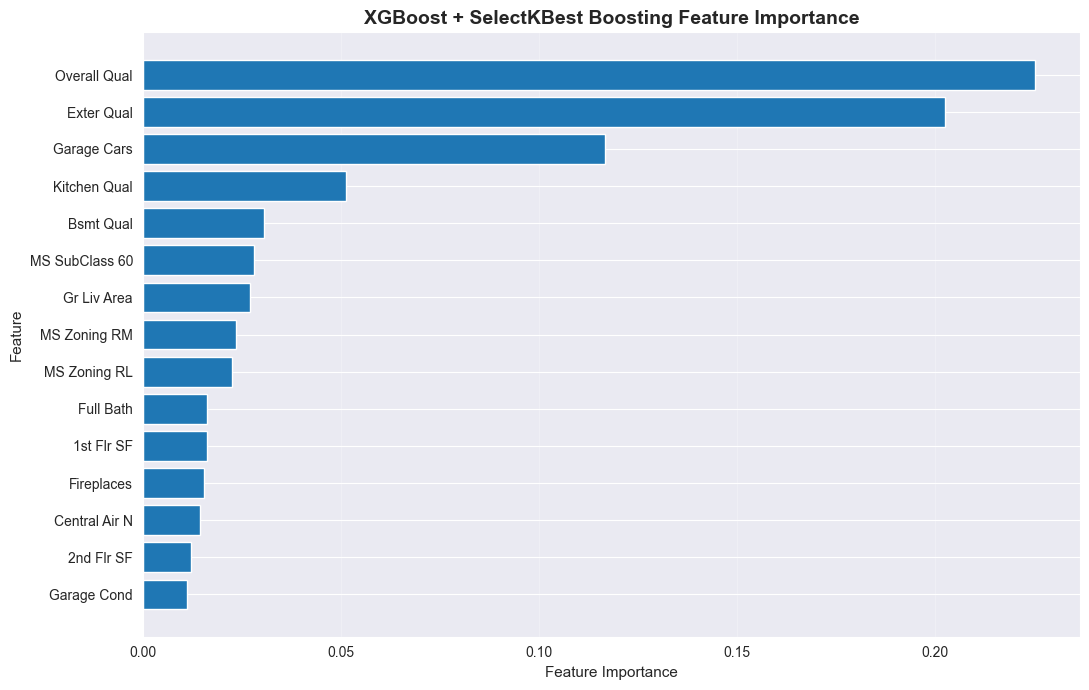

In [107]:
importance_df = plot_selected_model_feature_importance(
    model=results["XGBoost + SelectKBest"]["best_model"],
    top_n=15,
    title="XGBoost + SelectKBest Boosting Feature Importance"
)

Вывод:

Для XGBoost наиболее важными признаками стали Overall Qual и Exter Qual, то есть общее качество дома и качество внешней отделки. Также модель сильно учитывает Garage Cars, Kitchen Qual и Bsmt Qual.

В целом, XGBoost больше опирается на качественные характеристики дома, а не только на площадь.

**Residuals**

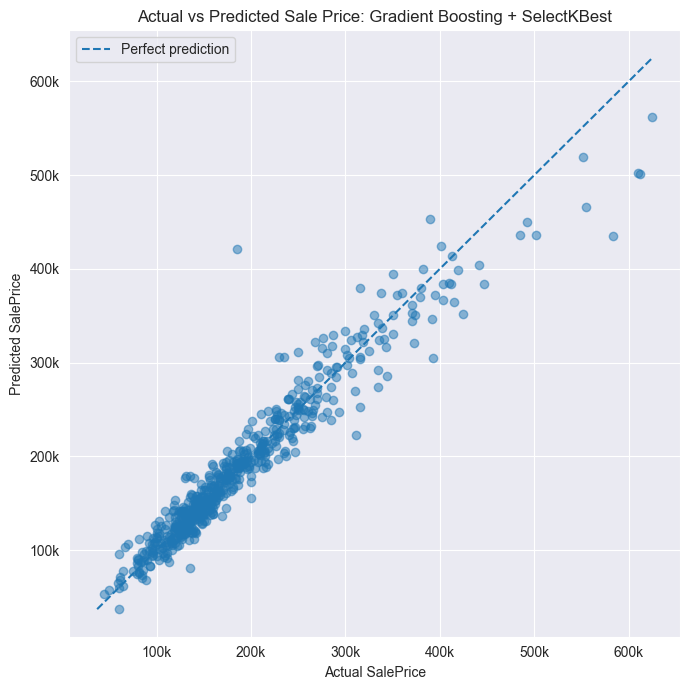

In [108]:
best_model = results["Gradient Boosting + SelectKBest"]["best_model"]

y_pred = best_model.predict(X_test)

plot_actual_vs_predicted(
    y_true=y_test,
    y_pred=y_pred,
    target_name="SalePrice", 
    title="Actual vs Predicted Sale Price: Gradient Boosting + SelectKBest"
)

Вывод: 

В целом, по графику видно, что модель хорошо предсказывает цену - большинство точек расположены близко рядом в диагональю идеального предсказания. Тем не менее, есть некоторые проблемы в предсказании стоимости дорогих домов - модель часто занижает их. 

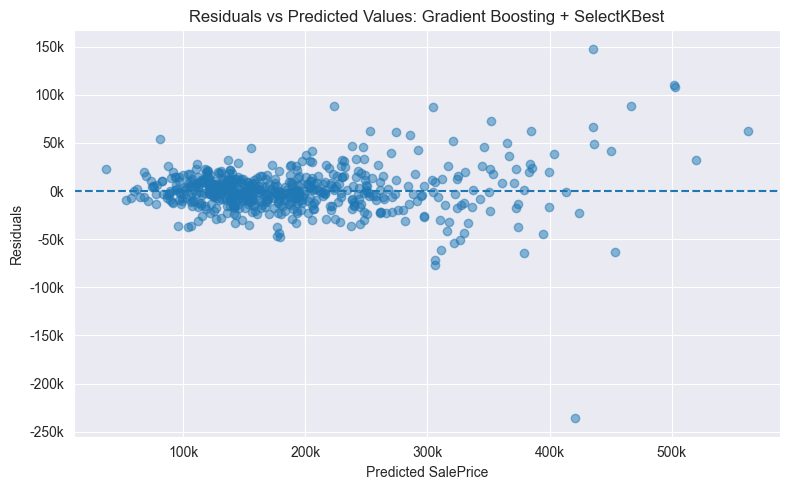

In [109]:
residuals = plot_residuals(
    y_true=y_test,
    y_pred=y_pred,
    title="Residuals vs Predicted Values: Gradient Boosting + SelectKBest"
)

Вывод:

На графике остатков можно точно также заметить, что у модели есть проблемы с предсказанием больших стоимостей. Также заметна гетероскедастичность остатков. 

**Пример ошибочного предсказания**

In [113]:
error_examples = X_test.copy()

error_examples["Actual SalePrice"] = y_test
error_examples["Predicted SalePrice"] = y_pred
error_examples["Residual"] = error_examples["Actual SalePrice"] - error_examples["Predicted SalePrice"]
error_examples["Absolute Error"] = error_examples["Residual"].abs()

error_examples_sorted = error_examples.sort_values(
    by="Absolute Error",
    ascending=False
)

error_examples_sorted[[
    "Actual SalePrice",
    "Predicted SalePrice",
    "Residual",
    "Absolute Error",
    "Gr Liv Area",
    "Overall Qual",
    "Garage Area",
    "Total Bsmt SF",
    "Year Built",
    "Neighborhood"
]].head(10)


worst_example = error_examples_sorted.iloc[0]

print(f"Actual price: {worst_example['Actual SalePrice']:,.0f}")
print(f"Predicted price: {worst_example['Predicted SalePrice']:,.0f}")
print(f"Residual: {worst_example['Residual']:,.0f}")
print(f"Absolute error: {worst_example['Absolute Error']:,.0f}")

Actual price: 184,750
Predicted price: 420,813
Residual: -236,063
Absolute error: 236,063


In [115]:
worst_example = error_examples_sorted.iloc[0]

worst_example[
    [
        "Actual SalePrice",
        "Predicted SalePrice",
        "Residual",
        "Absolute Error",
        "Gr Liv Area",
        "Overall Qual",
        "Overall Cond",
        "Garage Area",
        "Garage Cars",
        "Total Bsmt SF",
        "Year Built",
        "Year Remod/Add",
        "Neighborhood",
        "Kitchen Qual",
        "Exter Qual",
        "Bsmt Qual"
    ]
]

Actual SalePrice              184750
Predicted SalePrice    420812.747497
Residual              -236062.747497
Absolute Error         236062.747497
Gr Liv Area                     4676
Overall Qual                      10
Overall Cond                       5
Garage Area                    884.0
Garage Cars                      3.0
Total Bsmt SF                 3138.0
Year Built                      2007
Year Remod/Add                  2008
Neighborhood                 Edwards
Kitchen Qual                      Ex
Exter Qual                        Ex
Bsmt Qual                         Ex
Name: 2182, dtype: object

Вывод: 

В данном примере модель сильно переоценила стоимость дома: фактическая цена составила 184,750, тогда как предсказанная цена была 420,813. Ошибка составила 236,063. 

Такое предсказание можно объяснить тем, что объект имеет характеристики, которые модель обычно связывает с высокой стоимостью: очень большую жилую площадь, максимальную оценку качества, большой подвал, гараж на 3 машины, а также отличные оценки качества для кухни, внешней отделки и подвала. 

## 8. Выводы и следующие шаги

**Какую модель лучше выбрать и почему?**

По результатам сравнения моделей лучшей можно считать Gradient Boosting + SelectKBest, так как она показала наименьшее значение Validation RMSE и самый высокий Validation R² среди рассмотренных моделей. Также она показывает относительно умеренный коэффициент переобучения. 

**Что улучшить при большем времени?**

При наличии большего времени модель можно было бы улучшить несколькими способами:

* Можно было бы добавить новые макроэкономические признаки: уровень инфляции, состояние экономики и общий тренд рынка недвижимости. Это позволило бы модели учитывать не только характеристики самого дома, но и внешний экономический контекст. Для этого датасета это было бы очень важно: в нем продажи происходили в период с 2006 по 2010 год, а в 2008 году в США произошел финансовый кризис, напрямую связанный с рынком недвижимости. 

* Также, сли не исключать год и месяц продажи из датасета, можно было бы добавить сезонный компонент. Например, спрос на недвижимость может меняться в зависимости от месяца или времени года. 

* Еще можно было бы улучшить отбор признаков. Несмотря на то что SelectKBest помог уменьшить количество переменных, при большем времени можно было бы протестировать и другие методы. Возможно, некоторые из них могли бы улучшить ситуацию еще больше. 

* И поработать с проблемами переобучения моделей. 